# Load the MLFlow model locally and try predictions

## Prerequisites

1. You need to have run successfully the training notebook related to this model, available in this same folder, where at the end of the notebook, after training the model, it downloads the 'artifacts' with the MLFlow model folder ("./artifact_downloads/outputs/mlflow-model").

2. Create a conda environment with the 'conda.yaml' file provided within the "mlflow-model" folder, doing like the following:
     1. if you are running this notebook on a windows machine, Please remove "Pycocotools" and "recordclass" lines from conda.yaml and have c++ build tools( https://visualstudio.microsoft.com/visual-cpp-build-tools/ ) installed before running the below steps

   1. (base) /> conda env create --file conda.yaml --name automl-model-image-object-detection-env
   
   1. (base) /> conda activate automl-model-image-object-detection-env
   
   1. (automl-model-image-object-detection-env) /> conda install jupyter nb_conda

3. Run Jupyter and make sure you are using the related 'automl-model-image-object-detection-env' Kernel.

4. Run this notebook.


If the MLFlow model files were downloaded successfully by the training notebook, you should see the files here.

In [4]:
! pip install azure-ai-ml

In [54]:
from azure.ai.ml import MLClient
from azure.ai.ml.entities import Data
from azure.ai.ml.constants import AssetTypes
from azure.identity import DefaultAzureCredential

credential = DefaultAzureCredential()

ml_client = MLClient.from_config(credential)

Found the config file in: /config.json


In [2]:
model_name = "custom-trained-fridge-detection"

In [3]:
import os

# Local dir where you have downloaded and saved the artifacts
local_dir = model_name

mlflow_model_dir = os.path.join(local_dir, "mlflow-model")

if not os.path.isdir(mlflow_model_dir):
    ml_client.models.download(name=model_name, version=1)

In [4]:
# Show the contents of the MLFlow model folder
print(mlflow_model_dir)
os.listdir(mlflow_model_dir)

# You should see a list of files such as the following:
# ['artifacts', 'conda.yaml', 'MLmodel', 'python_env.yaml', 'python_model.pkl', 'requirements.txt']

custom-trained-fridge-detection/mlflow-model


['.amlignore',
 '.amlignore.amltmp',
 'conda.yaml',
 'MLmodel',
 'python_env.yaml',
 'python_model.pkl',
 'requirements.txt',
 'artifacts']

Open a Terminal and run:
```
ENV_NAME="custom-trained-fridge-detection"

conda env create --name $ENV_NAME --file=($ENV_NAME + "/mlflow-model/conda.yaml")
conda activate $ENV_NAME
conda install jupyter nb_conda azure-ai-ml -y
pip install opencensus-ext-logging mltable
ipython kernel install --user --name=$ENV_NAME
```

Now select the kernel that was just created in the top right from the dropdown.

### Load the scoring data into a Pandas DataFrame

Load scoring images into a Pandas DataFrame in order to try some predictions with it.

In [28]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
import mltable
dataset_name = "combined_dataset"
data_asset = ml_client.data.get(dataset_name, version="5")
tbl = mltable.load(f'azureml:/{data_asset.id}')
df = tbl.to_pandas_dataframe()

In [29]:
df.head(5)

,image_url,label,label_confidence,labeler,updated_by,approved_by,labeling_time_in_seconds,label_creation_time,image_details
0,workspaceblobstore/odFridgeObjects/images/85.jpg,"[{'label': 'beverage', 'topX': 0.5949570783, 'topY': 0.3741293532, 'bottomX': 0.7516645231, 'bottomY': 0.7154228856}, {'label': 'beverage', 'topX': 0.4302814584, 'topY': 0.3253731343, 'bottomX': 0.59230102, 'bottomY': 0.6995024876}, {'label': 'beverage', 'topX': 0.0810097808, 'topY': 0.2985074627, 'bottomX': 0.4661382466, 'bottomY': 0.7154228856}]","[1.0, 1.0, 1.0]",system_import,,Julian Gimbel,0.0,2024-10-29T14:35:51.465725Z,"{'width': 499, 'height': 666}"
1,workspaceblobstore/odFridgeObjects/images/45.jpg,"[{'label': 'beverage', 'topX': 0.4010648162, 'topY': 0.2577114428, 'bottomX': 0.6533903628, 'bottomY': 0.7711442786}, {'label': 'beverage', 'topX': 0.2098286124, 'topY': 0.2995024876, 'bottomX': 0.4170011665, 'bottomY': 0.7572139303}, {'label': 'beverage', 'topX': 0.6069093411, 'topY': 0.3383084577, 'bottomX': 0.8286902163, 'bottomY': 0.7393034826}]","[1.0, 1.0, 1.0]",system_import,,Julian Gimbel,0.0,2024-10-29T14:35:51.6259534Z,"{'width': 499, 'height': 666}"
2,workspaceblobstore/odFridgeObjects/images/72.jpg,"[{'label': 'beverage', 'topX': 0.227092992, 'topY': 0.2786069652, 'bottomX': 0.4701223342, 'bottomY': 0.7333333333}, {'label': 'beverage', 'topX': 0.482074597, 'topY': 0.3144278607, 'bottomX': 0.6533903628, 'bottomY': 0.6776119403}, {'label': 'beverage', 'topX': 0.7516645231, 'topY': 0.3651741294, 'bottomX': 0.9575090479, 'bottomY': 0.728358209}]","[1.0, 1.0, 1.0]",system_import,,Julian Gimbel,0.0,2024-10-29T14:35:51.7631199Z,"{'width': 499, 'height': 666}"
3,workspaceblobstore/odFridgeObjects/images/98.jpg,"[{'label': 'beverage', 'topX': 0.110226423, 'topY': 0.368159204, 'bottomX': 0.8114258367, 'bottomY': 0.7154228856}]",[1.0],system_import,,Julian Gimbel,0.0,2024-10-29T14:35:51.9138834Z,"{'width': 499, 'height': 666}"
4,workspaceblobstore/odFridgeObjects/images/27.jpg,"[{'label': 'beverage', 'topX': 0.0730416056, 'topY': 0.3174129353, 'bottomX': 0.3213830646, 'bottomY': 0.7552238806}, {'label': 'beverage', 'topX': 0.3917686119, 'topY': 0.2527363184, 'bottomX': 0.6108934286, 'bottomY': 0.7611940299}]","[1.0, 1.0]",system_import,,Julian Gimbel,0.0,2024-10-29T14:35:52.0606052Z,"{'width': 499, 'height': 666}"


In [30]:
# the model expects a column `image` containing a base64 encoded image
import base64
df["image"] = df["image_url"].apply(lambda x: base64.encodebytes(x.open().read()).decode("utf-8"))

## Load the best model in memory

Load the model using MLflow flavor. Check MLmodel under the downloaded folder (artifact_downloads/outputs/mlflow-model). For this particular example (and for AutoML for Images scenario), MLmodel file will describe python_function flavor. We show how to load model using pyfunc flavor. For more information on MLflow flavors, visit: https://www.mlflow.org/docs/latest/models.html#storage-format

Loading the models locally assume that you are running the notebook in an environment compatible with the model. The list of dependencies that is expected by the model is specified in the MLFlow model produced by AutoML (in the 'conda.yaml' file within the mlflow-model folder).

In [31]:
import mlflow.pyfunc

In [32]:
# Way #1: Get the MLFlow model from the downloaded MLFlow model files
# import azureml.train.automl
print(mlflow_model_dir)
pyfunc_model = mlflow.pyfunc.load_model(mlflow_model_dir)

custom-trained-fridge-detection/mlflow-model


2025/01/21 10:45:24 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - asttokens (current: 2.0.5, required: asttokens==3.0.0)
 - azure-identity (current: 1.17.1, required: azure-identity==1.19.0)
 - cachetools (current: 5.3.3, required: cachetools==5.5.0)
 - comm (current: 0.2.1, required: comm==0.2.2)
 - exceptiongroup (current: 1.2.0, required: exceptiongroup==1.2.2)
 - googleapis-common-protos (current: 1.63.2, required: googleapis-common-protos==1.66.0)
 - jupyter-client (current: 7.4.9, required: jupyter-client==8.6.3)
 - matplotlib-inline (current: 0.1.6, required: matplotlib-inline==0.1.7)
 - msal (current: 1.25.0, required: msal==1.31.1)
 - opencensus-ext-azure (current: 1.1.12, required: opencensus-ext-azure==1.1.13)
 - prompt-toolkit (current: 3.0.43, required: prompt-toolkit==3.0.48)
 - propcache (current: 0.2.0, required: propcache==0.2.1)
 - pure-eval (current: 0.2.2, required: pu

In [34]:
# Make the predictions
result_df = pyfunc_model.predict(df)
result_df.head()

Attempted to log scalar metric total_score_time_sec:
5.405308723449707
Attempted to log scalar metric per_image_avg_score_time_sec:
0.06756635904312133


,boxes
0,"[{'box': {'topX': 0.07998509724934896, 'topY': 0.2961886024475098, 'bottomX': 0.46841039021809894, 'bottomY': 0.7080909729003906}, 'label': 'beverage', 'score': 0.9990739822387695}, {'box': {'topX': 0.5905349222819011, 'topY': 0.3725210952758789, 'bottomX': 0.7551921081542968, 'bottomY': 0.7271115112304688}, 'label': 'beverage', 'score': 0.9989365935325623}, {'box': {'topX': 0.43160659790039063, 'topY': 0.32225688934326174, 'bottomX': 0.5986054992675781, 'bottomY': 0.6988414001464843}, 'label': 'beverage', 'score': 0.9987826943397522}]"
1,"[{'box': {'topX': 0.39920824686686196, 'topY': 0.25941307067871094, 'bottomX': 0.6595259602864584, 'bottomY': 0.7731137847900391}, 'label': 'beverage', 'score': 0.9995383024215698}, {'box': {'topX': 0.19964492797851563, 'topY': 0.3054532051086426, 'bottomX': 0.42031646728515626, 'bottomY': 0.7525975036621094}, 'label': 'beverage', 'score': 0.9985270500183105}, {'box': {'topX': 0.6125601196289062, 'topY': 0.3464232635498047, 'bottomX': 0.8154930623372396, 'bottomY': 0.74220947265625}, 'label': 'beverage', 'score': 0.9984704852104187}]"
2,"[{'box': {'topX': 0.21662195841471354, 'topY': 0.2678942108154297, 'bottomX': 0.4788433329264323, 'bottomY': 0.7395439147949219}, 'label': 'beverage', 'score': 0.9988356232643127}, {'box': {'topX': 0.48474263509114585, 'topY': 0.3099179458618164, 'bottomX': 0.6503629557291667, 'bottomY': 0.6851853942871093}, 'label': 'beverage', 'score': 0.9987925291061401}, {'box': {'topX': 0.7478138732910157, 'topY': 0.3638893127441406, 'bottomX': 0.9633595784505208, 'bottomY': 0.7261630249023437}, 'label': 'beverage', 'score': 0.9982717037200928}]"
3,"[{'box': {'topX': 0.12015103658040364, 'topY': 0.3648462677001953, 'bottomX': 0.8102621459960937, 'bottomY': 0.7173361206054687}, 'label': 'beverage', 'score': 0.9986414313316345}]"
4,"[{'box': {'topX': 0.3886637878417969, 'topY': 0.25960712432861327, 'bottomX': 0.6150127665201823, 'bottomY': 0.7546919250488281}, 'label': 'beverage', 'score': 0.9989388585090637}, {'box': {'topX': 0.06922061920166016, 'topY': 0.3087014389038086, 'bottomX': 0.3306252034505208, 'bottomY': 0.7575738525390625}, 'label': 'beverage', 'score': 0.998748779296875}]"


## Visualize detections
Now that we have scored test images, we can visualize the bounding boxes for the first image.

beverage: [39.913, 197.262, 193.824, 274.327], 0.999
beverage: [294.677, 248.099, 82.164, 236.157], 0.999
beverage: [215.372, 214.623, 83.332, 250.805], 0.999


<Figure size 1800x1200 with 0 Axes>

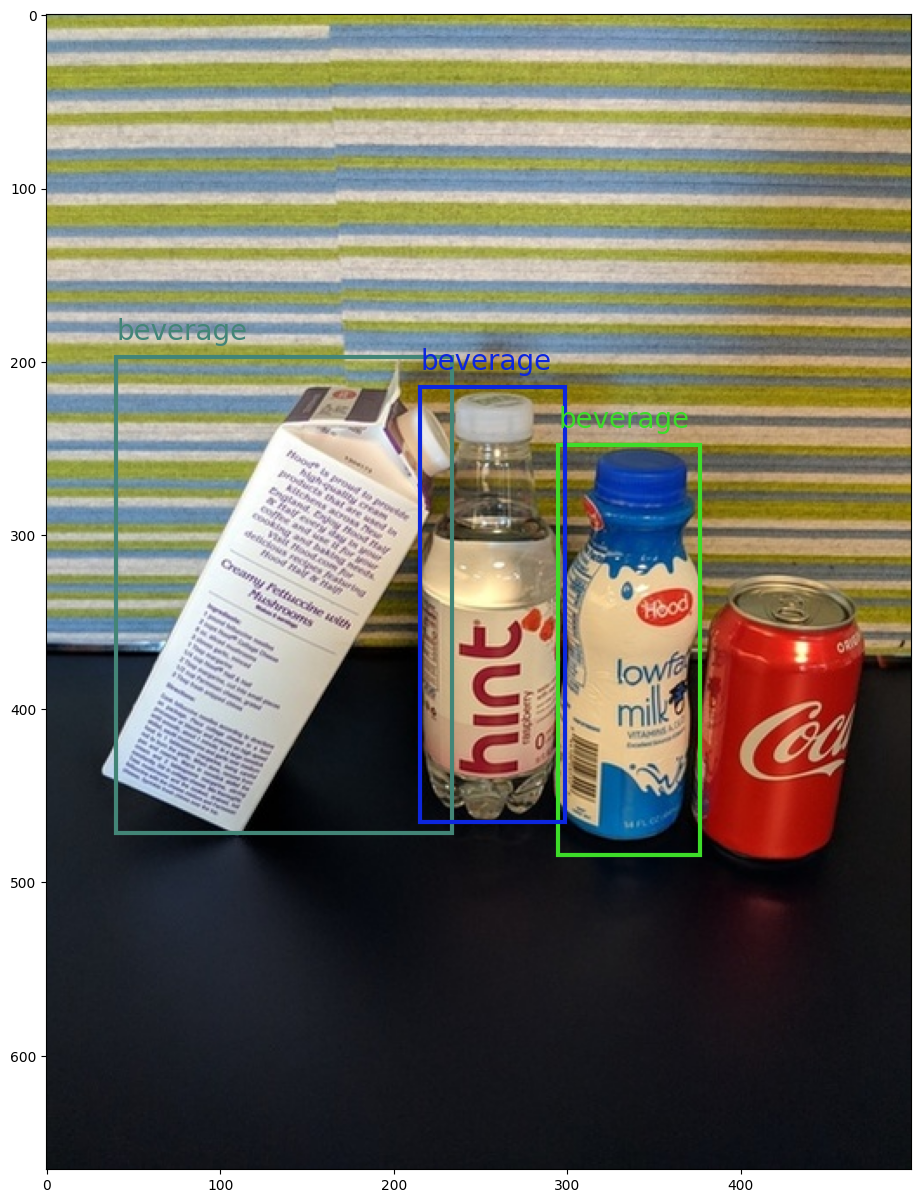

In [33]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
from PIL import Image
import numpy as np
import json

result = result_df.to_json(orient="records")

sample_image = df["image_url"][0].open()
detections = json.loads(result)[0]

IMAGE_SIZE = (18, 12)
plt.figure(figsize=IMAGE_SIZE)
img_np = mpimg.imread(sample_image, format="jpg")
img = Image.fromarray(img_np.astype("uint8"), "RGB")
x, y = img.size

fig, ax = plt.subplots(1, figsize=(15, 15))
# Display the image
ax.imshow(img_np)

# draw box and label for each detection
for detect in detections["boxes"]:
    label = detect["label"]
    box = detect["box"]
    conf_score = detect["score"]
    if conf_score > 0.6:
        ymin, xmin, ymax, xmax = (
            box["topY"],
            box["topX"],
            box["bottomY"],
            box["bottomX"],
        )
        topleft_x, topleft_y = x * xmin, y * ymin
        width, height = x * (xmax - xmin), y * (ymax - ymin)
        print(
            f"{detect['label']}: [{round(topleft_x, 3)}, {round(topleft_y, 3)}, "
            f"{round(width, 3)}, {round(height, 3)}], {round(conf_score, 3)}"
        )

        color = np.random.rand(3)  #'red'
        rect = patches.Rectangle(
            (topleft_x, topleft_y),
            width,
            height,
            linewidth=3,
            edgecolor=color,
            facecolor="none",
        )

        ax.add_patch(rect)
        plt.text(topleft_x, topleft_y - 10, label, color=color, fontsize=20)
plt.show()

## Save detections as new ML Table

In [36]:
df.head()


,image_url,label,label_confidence,labeler,updated_by,approved_by,labeling_time_in_seconds,label_creation_time,image_details,image,result
0,workspaceblobstore/odFridgeObjects/images/85.jpg,"[{'label': 'beverage', 'topX': 0.5949570783, 'topY': 0.3741293532, 'bottomX': 0.7516645231, 'bottomY': 0.7154228856}, {'label': 'beverage', 'topX': 0.4302814584, 'topY': 0.3253731343, 'bottomX': 0.59230102, 'bottomY': 0.6995024876}, {'label': 'beverage', 'topX': 0.0810097808, 'topY': 0.2985074627, 'bottomX': 0.4661382466, 'bottomY': 0.7154228856}]","[1.0, 1.0, 1.0]",system_import,,Julian Gimbel,0.0,2024-10-29T14:35:51.465725Z,"{'width': 499, 'height': 666}",...\n,"[{'box': {'topX': 0.07998509724934896, 'topY': 0.2961886024475098, 'bottomX': 0.46841039021809894, 'bottomY': 0.7080909729003906}, 'label': 'beverage', 'score': 0.9990739822387695}, {'box': {'topX': 0.5905349222819011, 'topY': 0.3725210952758789, 'bottomX': 0.7551921081542968, 'bottomY': 0.7271115112304688}, 'label': 'beverage', 'score': 0.9989365935325623}, {'box': {'topX': 0.43160659790039063, 'topY': 0.32225688934326174, 'bottomX': 0.5986054992675781, 'bottomY': 0.6988414001464843}, 'label': 'beverage', 'score': 0.9987826943397522}]"
1,workspaceblobstore/odFridgeObjects/images/45.jpg,"[{'label': 'beverage', 'topX': 0.4010648162, 'topY': 0.2577114428, 'bottomX': 0.6533903628, 'bottomY': 0.7711442786}, {'label': 'beverage', 'topX': 0.2098286124, 'topY': 0.2995024876, 'bottomX': 0.4170011665, 'bottomY': 0.7572139303}, {'label': 'beverage', 'topX': 0.6069093411, 'topY': 0.3383084577, 'bottomX': 0.8286902163, 'bottomY': 0.7393034826}]","[1.0, 1.0, 1.0]",system_import,,Julian Gimbel,0.0,2024-10-29T14:35:51.6259534Z,"{'width': 499, 'height': 666}",...\nQDn94r/qMZCuUL//2Q==\n,"[{'box': {'topX': 0.39920824686686196, 'topY': 0.25941307067871094, 'bottomX': 0.6595259602864584, 'bottomY': 0.7731137847900391}, 'label': 'beverage', 'score': 0.9995383024215698}, {'box': {'topX': 0.19964492797851563, 'topY': 0.3054532051086426, 'bottomX': 0.42031646728515626, 'bottomY': 0.7525975036621094}, 'label': 'beverage', 'score': 0.9985270500183105}, {'box': {'topX': 0.6125601196289062, 'topY': 0.3464232635498047, 'bottomX': 0.8154930623372396, 'bottomY': 0.74220947265625}, 'label': 'beverage', 'score': 0.9984704852104187}]"
2,workspaceblobstore/odFridgeObjects/images/72.jpg,"[{'label': 'beverage', 'topX': 0.227092992, 'topY': 0.2786069652, 'bottomX': 0.4701223342, 'bottomY': 0.7333333333}, {'label': 'beverage', 'topX': 0.482074597, 'topY': 0.3144278607, 'bottomX': 0.6533903628, 'bottomY': 0.6776119403}, {'label': 'beverage', 'topX': 0.7516645231, 'topY': 0.3651741294, 'bottomX': 0.9575090479, 'bottomY': 0.728358209}]","[1.0, 1.0, 1.0]",system_import,,Julian Gimbel,0.0,2024-10-29T14:35:51.7631199Z,"{'width': 499, 'height': 666}",...\n,"[{'box': {'topX': 0.21662195841471354, 'topY': 0.2678942108154297, 'bottomX': 0.4788433329264323, 'bottomY': 0.7395439147949219}, 'label': 'beverage', 'score': 0.9988356232643127}, {'box': {'topX': 0.48474263509114585, 'topY': 0.3099179458618164, 'bottomX': 0.6503629557291667, 'bottomY': 0.6851853942871093}, 'label': 'beverage', 'score': 0.9987925291061401}, {'box': {'topX': 0.7478138732910157, 'topY': 0.3638893127441406, 'bottomX': 0.9633595784505208, 'bottomY': 0.7261630249023437}, 'label': 'beverage', 'score': 0.9982717037200928}]"
3,workspaceblobstore/odFridgeObjects/images/98.jpg,"[{'label': 'beverage', 'topX': 0.110226423, 'topY': 0.368159204, 'bottomX': 0.8114258367, 'bottomY': 0.7154228856}]",[1.0],system_import,,Julian Gimbel,0.0,2024-10-29T14:35:51.9138834Z,"{'width': 499, 'height': 666}",...\n,"[{'box': {'topX': 0.12015103658040364, 'topY': 0.3648462677001953, 'bottomX': 0.8102621459960937, 'bottomY': 0.7173361206054687}, 'label': 'beverage', 'score': 0.9986414313316345}]"
4,workspaceblobstore/odFridgeObjects/images/27.jpg,"[{'label': 'beverage', 'topX': 0.0730416056, 'topY': 0.3174129353, 'bottomX': 0.3213830646, 'bottomY': 0.7552238806}, {'label': 'beverage', 

In [46]:
df["result"] = result_df
df["label"] = df.result.apply(lambda r: [{"label":i["label"], **i["box"]} for i in r])
df["label_confidence"] = df.result.apply(lambda r: [i["score"] for i in r])
df["labeler"] = model_name
df["updated_by"] = ""
df["approved_by"] = ""
df["labeling_time_in_seconds"] = 0
df["label_creation_time"] = pd.Timestamp.now()
df = df[["image_url", "label", "label_confidence", "labeler", "updated_by", "approved_by", "labeling_time_in_seconds", "label_creation_time"]]
df.head()

/tmp/ipykernel_10097/3832077512.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["result"] = result_df
/tmp/ipykernel_10097/3832077512.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"] = df.result.apply(lambda r: [{"label":i["label"], **i["box"]} for i in r])
/tmp/ipykernel_10097/3832077512.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

,image_url,label,label_confidence,labeler,updated_by,approved_by,labeling_time_in_seconds,label_creation_time
0,workspaceblobstore/odFridgeObjects/images/85.jpg,"[{'label': 'beverage', 'topX': 0.07998509724934896, 'topY': 0.2961886024475098, 'bottomX': 0.46841039021809894, 'bottomY': 0.7080909729003906}, {'label': 'beverage', 'topX': 0.5905349222819011, 'topY': 0.3725210952758789, 'bottomX': 0.7551921081542968, 'bottomY': 0.7271115112304688}, {'label': 'beverage', 'topX': 0.43160659790039063, 'topY': 0.32225688934326174, 'bottomX': 0.5986054992675781, 'bottomY': 0.6988414001464843}]","[0.9990739822387695, 0.9989365935325623, 0.9987826943397522]",custom-trained-fridge-detection,,,0,2025-01-21 11:03:28.585327
1,workspaceblobstore/odFridgeObjects/images/45.jpg,"[{'label': 'beverage', 'topX': 0.39920824686686196, 'topY': 0.25941307067871094, 'bottomX': 0.6595259602864584, 'bottomY': 0.7731137847900391}, {'label': 'beverage', 'topX': 0.19964492797851563, 'topY': 0.3054532051086426, 'bottomX': 0.42031646728515626, 'bottomY': 0.7525975036621094}, {'label': 'beverage', 'topX': 0.6125601196289062, 'topY': 0.3464232635498047, 'bottomX': 0.8154930623372396, 'bottomY': 0.74220947265625}]","[0.9995383024215698, 0.9985270500183105, 0.9984704852104187]",custom-trained-fridge-detection,,,0,2025-01-21 11:03:28.585327
2,workspaceblobstore/odFridgeObjects/images/72.jpg,"[{'label': 'beverage', 'topX': 0.21662195841471354, 'topY': 0.2678942108154297, 'bottomX': 0.4788433329264323, 'bottomY': 0.7395439147949219}, {'label': 'beverage', 'topX': 0.48474263509114585, 'topY': 0.3099179458618164, 'bottomX': 0.6503629557291667, 'bottomY': 0.6851853942871093}, {'label': 'beverage', 'topX': 0.7478138732910157, 'topY': 0.3638893127441406, 'bottomX': 0.9633595784505208, 'bottomY': 0.7261630249023437}]","[0.9988356232643127, 0.9987925291061401, 0.9982717037200928]",custom-trained-fridge-detection,,,0,2025-01-21 11:03:28.585327
3,workspaceblobstore/odFridgeObjects/images/98.jpg,"[{'label': 'beverage', 'topX': 0.12015103658040364, 'topY': 0.3648462677001953, 'bottomX': 0.8102621459960937, 'bottomY': 0.7173361206054687}]",[0.9986414313316345],custom-trained-fridge-detection,,,0,2025-01-21 11:03:28.585327
4,workspaceblobstore/odFridgeObjects/images/27.jpg,"[{'label': 'beverage', 'topX': 0.3886637878417969, 'topY': 0.25960712432861327, 'bottomX': 0.6150127665201823, 'bottomY': 0.7546919250488281}, {'label': 'beverage', 'topX': 0.06922061920166016, 'topY': 0.3087014389038086, 'bottomX': 0.3306252034505208, 'bottomY': 0.7575738525390625}]","[0.9989388585090637, 0.998748779296875]",custom-trained-fridge-detection,,,0,2025-01-21 11:03:28.585327


# From here on the scored data is stored as a data asset similar to other notebook

In [47]:
new_dataset_name = "prelabeled_dataset"
new_dataset_description = "This is the dataset prelabeled by model: " + model_name

In [48]:
df.image_url = df.image_url.apply(
    lambda x: "azureml://subscriptions/" +
    x.arguments["subscription"] + 
    "/resourcegroups/" + x.arguments["resourceGroup"] +
    "/workspaces/" + x.arguments["workspaceName"] +
    "/datastores/" + x.arguments["datastoreName"] +
    "/paths" + x.resource_id.lstrip(x.arguments["datastoreName"])
    )

df.image_url = df.image_url.astype(str)

/tmp/ipykernel_10097/3114747740.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.image_url = df.image_url.apply(
/tmp/ipykernel_10097/3114747740.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.image_url = df.image_url.astype(str)


In [49]:
# print distinct lables so user can select the labels to filter on
distinct_labels = set()
for item_list in df['label']:
    for item in item_list:
        distinct_labels.add(item['label'])

distinct_labels = list(distinct_labels)
print(distinct_labels)

['beverage']


In [50]:
# optionally filter on subset of labels
labels_subset = []

def filter_labels(row, labels_subset):
    filtered_labels = [d for d in row['label'] if d['label'] in labels_subset]
    filtered_confidence = [row['label_confidence'][i] for i, d in enumerate(row['label']) if d['label'] in labels_subset]
    return pd.Series([filtered_labels, filtered_confidence])


if labels_subset:
    new_dataset_description = new_dataset_description + " filtered for the following labels: " + ", ".join(labels_subset)
    df[['label', 'label_confidence']] = df.apply(filter_labels, labels_subset=labels_subset, axis=1)

df.label.head(5)

0    [{'label': 'beverage', 'topX': 0.07998509724934896, 'topY': 0.2961886024475098, 'bottomX': 0.46841039021809894, 'bottomY': 0.7080909729003906}, {'label': 'beverage', 'topX': 0.5905349222819011, 'topY': 0.3725210952758789, 'bottomX': 0.7551921081542968, 'bottomY': 0.7271115112304688}, {'label': 'beverage', 'topX': 0.43160659790039063, 'topY': 0.32225688934326174, 'bottomX': 0.5986054992675781, 'bottomY': 0.6988414001464843}]
1      [{'label': 'beverage', 'topX': 0.39920824686686196, 'topY': 0.25941307067871094, 'bottomX': 0.6595259602864584, 'bottomY': 0.7731137847900391}, {'label': 'beverage', 'topX': 0.19964492797851563, 'topY': 0.3054532051086426, 'bottomX': 0.42031646728515626, 'bottomY': 0.7525975036621094}, {'label': 'beverage', 'topX': 0.6125601196289062, 'topY': 0.3464232635498047, 'bottomX': 0.8154930623372396, 'bottomY': 0.74220947265625}]
2      [{'label': 'beverage', 'topX': 0.21662195841471354, 'topY': 0.2678942108154297, 'bottomX': 0.4788433329264323, 'bottomY': 0.739

In [51]:
folder = new_dataset_name
os.makedirs(folder, exist_ok=True)

filename = "labeledDatapoints_1.jsonl"
filename_with_folder = folder + "/" + filename

with open(filename_with_folder, "w") as f:
    f.write(df.to_json(orient='records', lines=True, force_ascii=False).replace("\\/","/"))

In [55]:
# create paths to the data files
paths = [{"file": filename_with_folder}]

# create an MLTable from the data files
tbl = mltable.from_json_lines_files(
    paths=paths
)

tbl = tbl.convert_column_types({"image_url": "stream_info"})

tbl.save(folder)

# Define the Data asset object
my_data = Data(
    path=folder,
    type=AssetTypes.MLTABLE,
    description=new_dataset_description,
    name=new_dataset_name
)

# Create the data asset in the workspace
ml_client.data.create_or_update(my_data)

Uploading prelabeled_dataset (0.05 MBs): 100%|██████████| 47803/47803 [00:00<00:00, 198604.04it/s]




Data({'path': 'azureml://subscriptions/5121ed4d-cbd2-4f4d-a566-99571d08db8f/resourcegroups/eco-azureml-rg/workspaces/eco-azureml/datastores/workspaceblobstore/paths/LocalUpload/08e103dd9667b8565bccd869801fa1c9/prelabeled_dataset/', 'skip_validation': False, 'mltable_schema_url': None, 'referenced_uris': ['labeledDatapoints_1.jsonl'], 'type': 'mltable', 'is_anonymous': False, 'auto_increment_version': False, 'auto_delete_setting': None, 'name': 'prelabeled_dataset', 'description': 'This is the dataset prelabeled by model: custom-trained-fridge-detection', 'tags': {}, 'properties': {}, 'print_as_yaml': False, 'id': '/subscriptions/5121ed4d-cbd2-4f4d-a566-99571d08db8f/resourceGroups/eco-azureml-rg/providers/Microsoft.MachineLearningServices/workspaces/eco-azureml/data/prelabeled_dataset/versions/1', 'Resource__source_path': '', 'base_path': '/mnt/batch/tasks/shared/LS_root/mounts/clusters/juliangimbelgpu/code/Users/juliangimbel/eco-project', 'creation_context': <azure.ai.ml.entities._syst

# Next Steps
You can see further examples of other AutoML tasks such as Regression, Image-Classification, NLP-Text-Classification, Time-Series-Forcasting, etc.